# APIs de Energia Renovável e Aprendizado de Máquina

Este notebook desenvolve as duas tarefas propostas:

1. **Classificação da fonte renovável (ANEEL/SIGA):** prever se um empreendimento é Solar, Eólica ou Hidráulica usando somente potência e localização.
2. **Regressão da radiação solar (Open-Meteo):** estimar a radiação solar horizontal média da hora em Petrolina (PE) a partir das condições meteorológicas e da hora local.

Os seis modelos são treinados com as mesmas regras de avaliação definidas no enunciado. As consultas às APIs são públicas e não utilizam tokens.

## 1. Imports e configuração

A semente `42` é usada nos modelos que possuem aleatoriedade e na divisão estratificada da classificação. Na regressão, a ordem temporal é preservada: as primeiras 80% das observações são treino e as últimas 20% são teste.

In [1]:
import json
import urllib.parse
import urllib.request
import csv
import os

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor, GradientBoostingRegressor

from sklearn.metrics import (
    accuracy_score, confusion_matrix, precision_score, recall_score, f1_score,
    mean_absolute_error, mean_squared_error, r2_score
)

RANDOM_STATE = 42
plt.rcParams["figure.figsize"] = (9, 5)
plt.rcParams["axes.grid"] = True
print("Ambiente preparado.")

Ambiente preparado.


## 2. Consulta das APIs e geração dos CSVs

As células abaixo reproduzem a preparação fornecida no notebook de apoio. Se a consulta online estiver indisponível, o notebook pode continuar usando os CSVs já gerados e presentes no repositório.

In [2]:
def consultar_api(endereco, parametros):
    url = endereco + "?" + urllib.parse.urlencode(parametros)
    try:
        with urllib.request.urlopen(url, timeout=100) as resposta:
            if resposta.status != 200:
                raise RuntimeError(f"HTTP {resposta.status}")
            return json.loads(resposta.read().decode("utf-8"))
    except Exception as erro:
        raise RuntimeError(f"Falha na consulta: {erro}") from erro

URL_ANEEL = "https://dadosabertos.aneel.gov.br/api/3/action/datastore_search"
ID_RECURSO = "11ec447d-698d-4ab8-977f-b424d5deee6a"
SIGLAS = ["UFV", "EOL", "UHE", "PCH", "CGH"]

URL_METEO = "https://archive-api.open-meteo.com/v1/archive"
parametros_meteo = {
    "latitude": -9.39,
    "longitude": -40.50,
    "start_date": "2025-04-01",
    "end_date": "2025-06-30",
    "timezone": "America/Recife",
    "hourly": ",".join([
        "temperature_2m", "relative_humidity_2m", "cloud_cover",
        "wind_speed_10m", "shortwave_radiation"
    ]),
}
print("APIs configuradas.")

APIs configuradas.


In [3]:
# Geração/atualização do CSV da ANEEL.
# False = usa os CSVs entregues (execução estável/reprodutível).
# True = consulta novamente a API pública e recria o CSV.
ATUALIZAR_DADOS = False

fontes = {"UFV": "Solar", "EOL": "Eólica", "UHE": "Hidráulica",
          "PCH": "Hidráulica", "CGH": "Hidráulica"}

def numero(valor):
    texto = str(valor).strip()
    if "," in texto:
        texto = texto.replace(".", "").replace(",", ".")
    try:
        return float(texto)
    except (ValueError, TypeError):
        return None

if ATUALIZAR_DADOS:
    try:
        registros_aneel = []
        for sigla in SIGLAS:
            parametros = {
                "resource_id": ID_RECURSO,
                "filters": json.dumps({"SigTipoGeracao": sigla}),
                "limit": 5000,
            }
            resposta = consultar_api(URL_ANEEL, parametros)
            if not resposta.get("success"):
                raise ValueError(f"Consulta da ANEEL falhou para {sigla}")
            registros_aneel.extend(resposta["result"]["records"])

        linhas_classificacao = []
        for registro in registros_aneel:
            potencia = numero(registro.get("MdaPotenciaOutorgadaKw"))
            latitude = numero(registro.get("NumCoordNEmpreendimento"))
            longitude = numero(registro.get("NumCoordEEmpreendimento"))
            fonte = fontes.get(registro.get("SigTipoGeracao"))
            if fonte and all(v is not None for v in (potencia, latitude, longitude)):
                linhas_classificacao.append([potencia, latitude, longitude, fonte])

        pd.DataFrame(
            linhas_classificacao,
            columns=["potencia_kw", "latitude", "longitude", "fonte"]
        ).to_csv("aneel_classificacao_orange.csv", index=False, encoding="utf-8-sig")
        print(f"ANEEL: {len(linhas_classificacao)} linhas válidas salvas.")
    except Exception as erro:
        if os.path.exists("aneel_classificacao_orange.csv"):
            print("API ANEEL indisponível; usando o CSV local já gerado.")
        else:
            raise
else:
    print("ATUALIZAR_DADOS=False: usando aneel_classificacao_orange.csv existente.")

ATUALIZAR_DADOS=False: usando aneel_classificacao_orange.csv existente.


In [4]:
# Geração/atualização do CSV do Open-Meteo.
if ATUALIZAR_DADOS:
    try:
        resposta_meteo = consultar_api(URL_METEO, parametros_meteo)
        horas_api = resposta_meteo["hourly"]

        linhas_regressao = []
        nomes_api = [
            "temperature_2m", "relative_humidity_2m", "cloud_cover",
            "wind_speed_10m", "shortwave_radiation"
        ]

        for indice, data_hora in enumerate(horas_api["time"]):
            hora = int(data_hora[11:13])
            valores = [horas_api[nome][indice] for nome in nomes_api]
            if 7 <= hora <= 17 and all(v is not None for v in valores):
                linhas_regressao.append([data_hora, *valores[:4], hora, valores[4]])

        pd.DataFrame(
            linhas_regressao,
            columns=["data_hora", "temperatura_c", "umidade_pct", "nuvens_pct",
                     "vento_kmh", "hora", "radiacao_w_m2"]
        ).to_csv("meteo_regressao_orange.csv", index=False, encoding="utf-8-sig")
        print(f"Open-Meteo: {len(linhas_regressao)} linhas válidas salvas.")
    except Exception as erro:
        if os.path.exists("meteo_regressao_orange.csv"):
            print("API Open-Meteo indisponível; usando o CSV local já gerado.")
        else:
            raise
else:
    print("ATUALIZAR_DADOS=False: usando meteo_regressao_orange.csv existente.")

ATUALIZAR_DADOS=False: usando meteo_regressao_orange.csv existente.


# Tarefa 1 — Classificação da fonte renovável

**Pergunta:** a partir da potência outorgada e da localização de um empreendimento, é possível classificar sua fonte como Solar, Eólica ou Hidráulica?

A coluna `fonte` é o alvo. Não serão usadas colunas que revelem diretamente a resposta, como sigla, nome, código CEG ou descrição.

In [5]:
aneel = pd.read_csv("aneel_classificacao_orange.csv")
print("Dimensões:", aneel.shape)
print("\nTipos:")
print(aneel.dtypes)
print("\nAusentes:")
print(aneel.isna().sum())
print("\nClasses:")
print(aneel["fonte"].value_counts())
display(aneel.describe(include="all").T)

Dimensões: (3876, 4)

Tipos:
potencia_kw    float64
latitude       float64
longitude      float64
fonte           object
dtype: object

Ausentes:
potencia_kw    0
latitude       0
longitude      0
fonte          0
dtype: int64

Classes:
fonte
Hidráulica    1476
Solar         1200
Eólica        1200
Name: count, dtype: int64


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
potencia_kw,3876.0,NaN,NaN,NaN,42014.681517,301636.587843,0.16,440.0,12680.0,30000.0,11233100.0
latitude,3876.0,NaN,NaN,NaN,-12.693951,9.500523,-33.722806,-21.14211,-10.469532,-4.127788,3.831392
longitude,3876.0,NaN,NaN,NaN,-46.158299,8.357453,-69.941389,-52.561817,-47.393697,-41.280013,0.0
fonte,3876,3,Hidráulica,1476,NaN,NaN,NaN,NaN,NaN,NaN,NaN


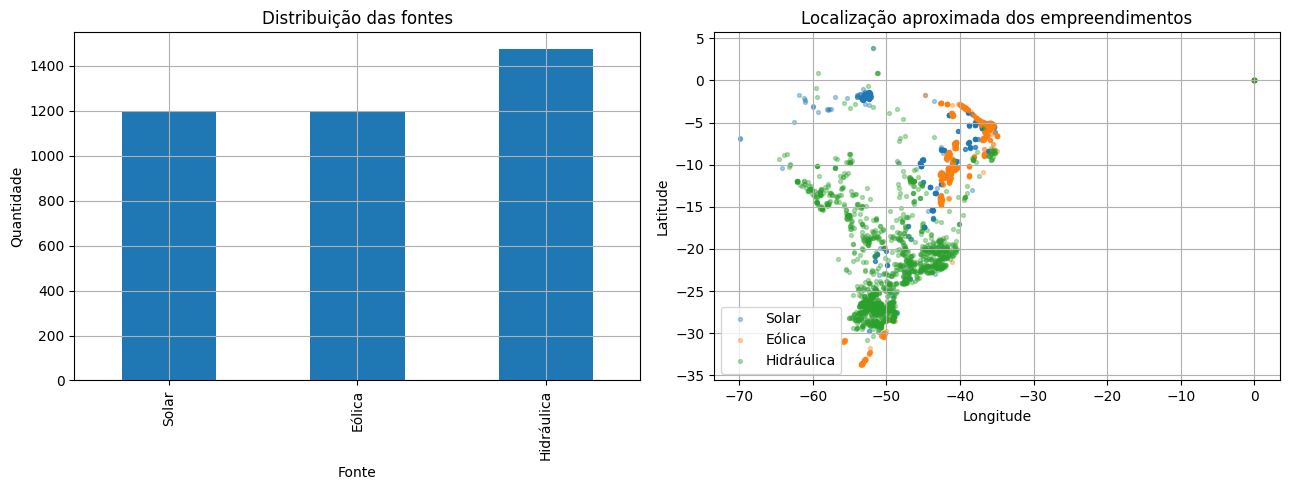

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

aneel["fonte"].value_counts().reindex(["Solar", "Eólica", "Hidráulica"]).plot(
    kind="bar", ax=axes[0]
)
axes[0].set_title("Distribuição das fontes")
axes[0].set_xlabel("Fonte")
axes[0].set_ylabel("Quantidade")

for fonte in ["Solar", "Eólica", "Hidráulica"]:
    subset = aneel[aneel["fonte"] == fonte]
    axes[1].scatter(subset["longitude"], subset["latitude"], s=8, alpha=0.35, label=fonte)
axes[1].set_title("Localização aproximada dos empreendimentos")
axes[1].set_xlabel("Longitude")
axes[1].set_ylabel("Latitude")
axes[1].legend()

plt.tight_layout()
plt.show()

### Definição de X e y e divisão estratificada

`X` contém apenas `potencia_kw`, `latitude` e `longitude`. `y` é `fonte`.

A divisão é 80% treino e 20% teste, com `stratify=y` para preservar aproximadamente a proporção das três classes nos dois conjuntos.

In [7]:
X_cls = aneel[["potencia_kw", "latitude", "longitude"]]
y_cls = aneel["fonte"]

X_train, X_test, y_train, y_test = train_test_split(
    X_cls, y_cls,
    test_size=0.20,
    stratify=y_cls,
    random_state=RANDOM_STATE
)

print("Treino:", X_train.shape, "Teste:", X_test.shape)
print("\nProporções no treino:")
print(y_train.value_counts(normalize=True).round(3))
print("\nProporções no teste:")
print(y_test.value_counts(normalize=True).round(3))

Treino: (3100, 3) Teste: (776, 3)

Proporções no treino:
fonte
Hidráulica    0.381
Solar         0.310
Eólica        0.310
Name: proportion, dtype: float64

Proporções no teste:
fonte
Hidráulica    0.381
Solar         0.309
Eólica        0.309
Name: proportion, dtype: float64


### Três classificadores

1. **Regressão Logística** — com padronização das entradas.
2. **KNN** — com padronização, pois o método depende de distâncias.
3. **Random Forest** — conjunto de árvores; não necessita de padronização.

As métricas Precision, Recall e F1 usam **média macro**, dando o mesmo peso às três classes.

In [8]:
classificadores = {
    "Regressão Logística": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(max_iter=2000, random_state=RANDOM_STATE))
    ]),
    "KNN": Pipeline([
        ("scaler", StandardScaler()),
        ("model", KNeighborsClassifier(n_neighbors=7))
    ]),
    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        class_weight="balanced"
    )
}

resultados_cls = []
predicoes_cls = {}

for nome, modelo in classificadores.items():
    modelo.fit(X_train, y_train)
    pred = modelo.predict(X_test)
    predicoes_cls[nome] = pred

    resultados_cls.append({
        "Algoritmo": nome,
        "Accuracy": accuracy_score(y_test, pred),
        "Precision (macro)": precision_score(y_test, pred, average="macro", zero_division=0),
        "Recall (macro)": recall_score(y_test, pred, average="macro", zero_division=0),
        "F1 (macro)": f1_score(y_test, pred, average="macro", zero_division=0)
    })

resultados_cls_df = pd.DataFrame(resultados_cls).sort_values("F1 (macro)", ascending=False)
display(resultados_cls_df.style.format({
    "Accuracy": "{:.4f}",
    "Precision (macro)": "{:.4f}",
    "Recall (macro)": "{:.4f}",
    "F1 (macro)": "{:.4f}"
}))

,Algoritmo,Accuracy,Precision (macro),Recall (macro),F1 (macro)
2,Random Forest,0.9755,0.9768,0.9739,0.9751
1,KNN,0.9652,0.9668,0.9633,0.9647
0,Regressão Logística,0.8247,0.8282,0.8214,0.8197


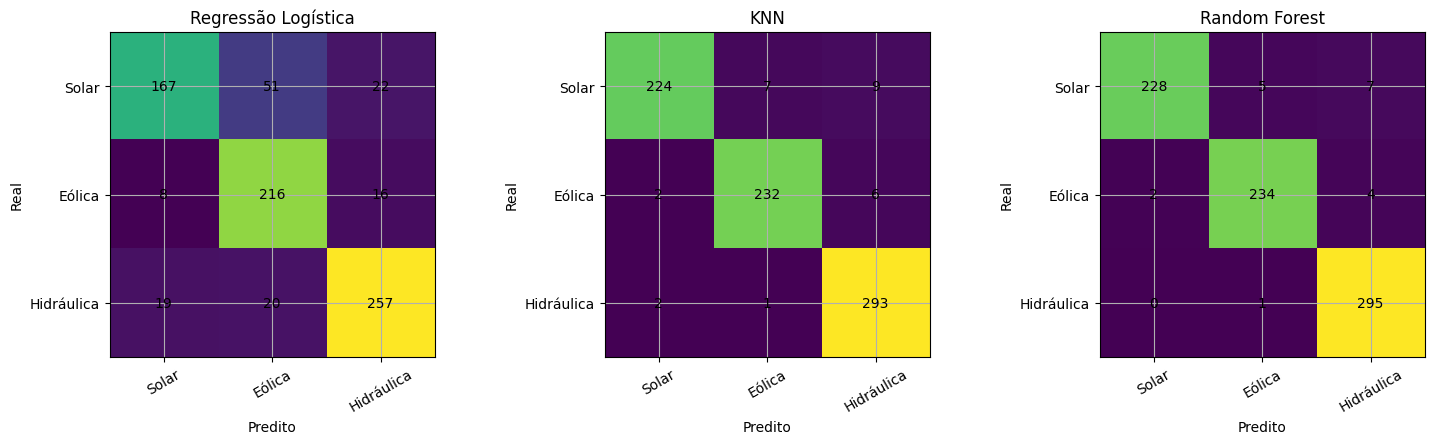

In [9]:
labels_cls = ["Solar", "Eólica", "Hidráulica"]

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, (nome, pred) in zip(axes, predicoes_cls.items()):
    cm = confusion_matrix(y_test, pred, labels=labels_cls)
    im = ax.imshow(cm)
    ax.set_title(nome)
    ax.set_xlabel("Predito")
    ax.set_ylabel("Real")
    ax.set_xticks(range(3), labels_cls, rotation=30)
    ax.set_yticks(range(3), labels_cls)
    for i in range(3):
        for j in range(3):
            ax.text(j, i, cm[i, j], ha="center", va="center")
plt.tight_layout()
plt.show()

In [10]:
melhor_cls = resultados_cls_df.iloc[0]["Algoritmo"]
print(f"Melhor classificador por F1 macro: {melhor_cls}")

for nome, pred in predicoes_cls.items():
    cm = confusion_matrix(y_test, pred, labels=labels_cls)
    erros = cm.copy()
    np.fill_diagonal(erros, 0)
    i, j = np.unravel_index(np.argmax(erros), erros.shape)
    print(f"{nome}: maior confusão = Real {labels_cls[i]} -> Predito {labels_cls[j]} ({erros[i,j]} casos).")

Melhor classificador por F1 macro: Random Forest
Regressão Logística: maior confusão = Real Solar -> Predito Eólica (51 casos).
KNN: maior confusão = Real Solar -> Predito Hidráulica (9 casos).
Random Forest: maior confusão = Real Solar -> Predito Hidráulica (7 casos).


### Interpretação da classificação

Os modelos conseguem aproveitar padrões de potência e localização, mas essas variáveis não determinam a fonte de forma única. A maior limitação é a sobreposição: empreendimentos de fontes diferentes podem ocupar regiões semelhantes e ter potências semelhantes. Além disso, o cadastro representa empreendimentos e suas características de outorga, não a energia efetivamente gerada.

A matriz de confusão deve ser lida observando quais classes aparecem fora da diagonal principal. A **Random Forest** apresentou o melhor F1 macro nesta execução, enquanto a Regressão Logística teve mais confusões entre classes.

# Tarefa 2 — Regressão da radiação solar

Dados horários estimados para **Petrolina (PE)**, aproximadamente `-9,39, -40,50`, de **01/04/2025 a 30/06/2025**, no fuso `America/Recife`. Foram mantidas apenas as horas locais de 7h a 17h.

In [11]:
meteo = pd.read_csv("meteo_regressao_orange.csv")
meteo["data_hora"] = pd.to_datetime(meteo["data_hora"])
meteo = meteo.sort_values("data_hora").reset_index(drop=True)

print("Dimensões:", meteo.shape)
print("\nAusentes:")
print(meteo.isna().sum())
print("\nPeríodo:", meteo["data_hora"].min(), "até", meteo["data_hora"].max())
display(meteo.describe().T)

Dimensões: (1001, 7)

Ausentes:
data_hora        0
temperatura_c    0
umidade_pct      0
nuvens_pct       0
vento_kmh        0
hora             0
radiacao_w_m2    0
dtype: int64

Período: 2025-04-01 07:00:00 até 2025-06-30 17:00:00


,count,mean,min,25%,50%,75%,max,std
data_hora,1001,2025-05-16 11:59:59.999999744,2025-04-01 07:00:00,2025-04-23 15:00:00,2025-05-16 12:00:00,2025-06-08 09:00:00,2025-06-30 17:00:00,NaN
temperatura_c,1001.0,28.885914,19.5,26.3,29.1,31.7,36.1,3.656514
umidade_pct,1001.0,50.544456,21.0,38.0,49.0,61.0,95.0,15.913965
nuvens_pct,1001.0,55.108891,0.0,19.0,54.0,98.0,100.0,37.851461
vento_kmh,1001.0,15.465435,2.3,12.2,15.4,19.0,30.1,4.923631
hora,1001.0,12.0,7.0,9.0,12.0,15.0,17.0,3.163858
radiacao_w_m2,1001.0,472.854146,13.0,250.0,466.0,696.0,1002.0,256.36895


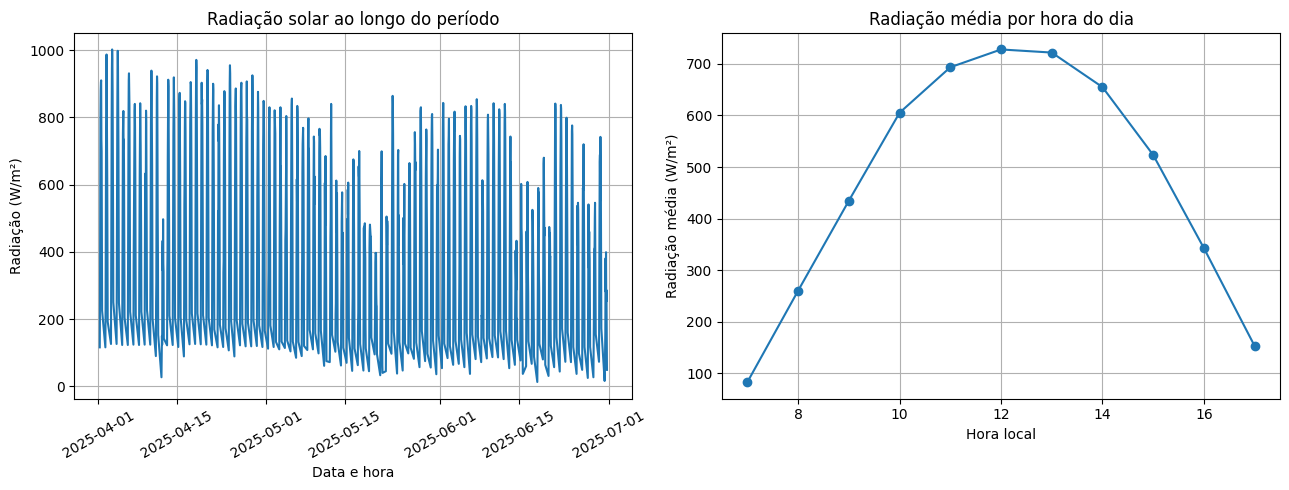

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(meteo["data_hora"], meteo["radiacao_w_m2"])
axes[0].set_title("Radiação solar ao longo do período")
axes[0].set_xlabel("Data e hora")
axes[0].set_ylabel("Radiação (W/m²)")
axes[0].tick_params(axis="x", rotation=30)

media_hora = meteo.groupby("hora")["radiacao_w_m2"].mean()
axes[1].plot(media_hora.index, media_hora.values, marker="o")
axes[1].set_title("Radiação média por hora do dia")
axes[1].set_xlabel("Hora local")
axes[1].set_ylabel("Radiação média (W/m²)")

plt.tight_layout()
plt.show()

### Definição de X e y e divisão temporal

As entradas são `temperatura_c`, `umidade_pct`, `nuvens_pct`, `vento_kmh` e `hora`. O alvo é `radiacao_w_m2`.

A coluna `data_hora` serve para ordenar e separar os dados, mas não entra diretamente em `X`. O corte é temporal, sem embaralhamento: primeiras 80% para treino e últimas 20% para teste.

In [13]:
X_reg = meteo[[
    "temperatura_c", "umidade_pct", "nuvens_pct", "vento_kmh", "hora"
]]
y_reg = meteo["radiacao_w_m2"]

corte = int(len(meteo) * 0.80)
X_train_r, X_test_r = X_reg.iloc[:corte], X_reg.iloc[corte:]
y_train_r, y_test_r = y_reg.iloc[:corte], y_reg.iloc[corte:]

print("Treino:", X_train_r.shape, "| Teste:", X_test_r.shape)
print("Última hora do treino:", meteo.iloc[corte-1]["data_hora"])
print("Primeira hora do teste:", meteo.iloc[corte]["data_hora"])

Treino: (800, 5) | Teste: (201, 5)
Última hora do treino: 2025-06-12 14:00:00
Primeira hora do teste: 2025-06-12 15:00:00


### Três regressores

1. **Regressão Linear**
2. **Random Forest Regressor**
3. **Gradient Boosting Regressor**

Todos usam exatamente a mesma divisão temporal. A comparação utiliza MAE, MSE e R².

In [14]:
regressores = {
    "Regressão Linear": LinearRegression(),
    "Random Forest Regressor": RandomForestRegressor(
        n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1
    ),
    "Gradient Boosting Regressor": GradientBoostingRegressor(
        n_estimators=200, learning_rate=0.05, max_depth=3,
        random_state=RANDOM_STATE
    )
}

resultados_reg = []
predicoes_reg = {}

for nome, modelo in regressores.items():
    modelo.fit(X_train_r, y_train_r)
    pred = modelo.predict(X_test_r)
    predicoes_reg[nome] = pred

    resultados_reg.append({
        "Algoritmo": nome,
        "MAE (W/m²)": mean_absolute_error(y_test_r, pred),
        "MSE ((W/m²)²)": mean_squared_error(y_test_r, pred),
        "R²": r2_score(y_test_r, pred)
    })

resultados_reg_df = pd.DataFrame(resultados_reg).sort_values("MAE (W/m²)")
display(resultados_reg_df.style.format({
    "MAE (W/m²)": "{:.3f}",
    "MSE ((W/m²)²)": "{:.3f}",
    "R²": "{:.4f}"
}))

,Algoritmo,MAE (W/m²),MSE ((W/m²)²),R²
1,Random Forest Regressor,66.399,7210.084,0.8463
2,Gradient Boosting Regressor,66.734,7373.934,0.8428
0,Regressão Linear,145.205,30034.201,0.3598


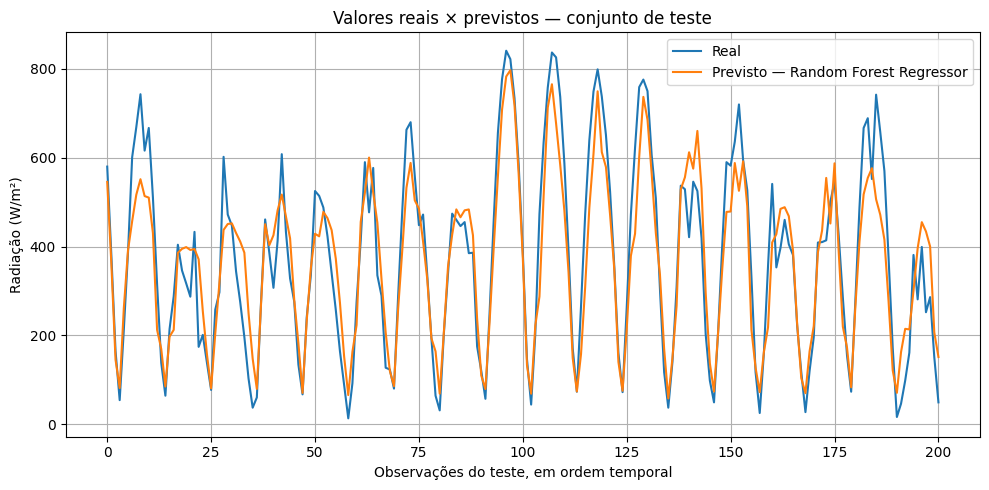

Melhor regressor por MAE: Random Forest Regressor


In [15]:
# Gráfico de valores reais x previstos do melhor modelo por MAE
melhor_reg = resultados_reg_df.iloc[0]["Algoritmo"]
pred_melhor = predicoes_reg[melhor_reg]

plt.figure(figsize=(10, 5))
plt.plot(y_test_r.to_numpy(), label="Real")
plt.plot(pred_melhor, label=f"Previsto — {melhor_reg}")
plt.title("Valores reais × previstos — conjunto de teste")
plt.xlabel("Observações do teste, em ordem temporal")
plt.ylabel("Radiação (W/m²)")
plt.legend()
plt.tight_layout()
plt.show()

print(f"Melhor regressor por MAE: {melhor_reg}")

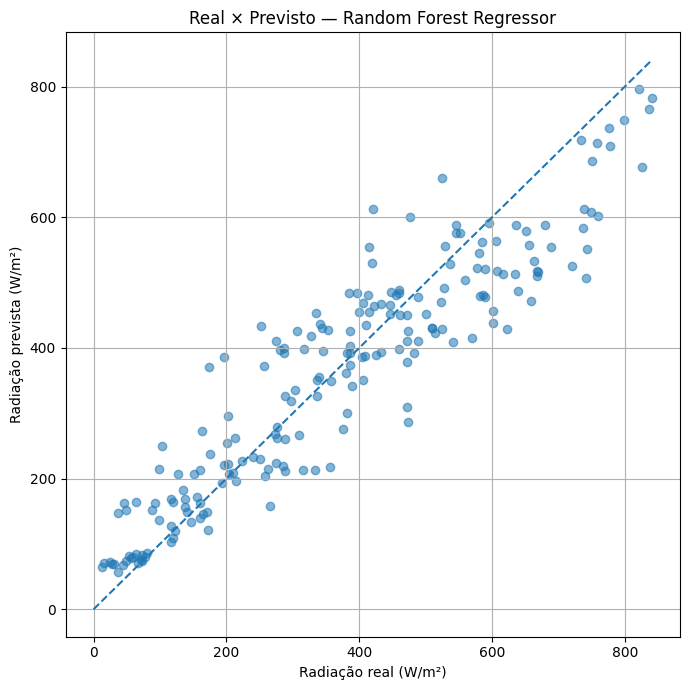

In [16]:
# Gráfico solicitado de valores reais × previstos, com linha de referência.
plt.figure(figsize=(7, 7))
plt.scatter(y_test_r, pred_melhor, alpha=0.55)
limite = max(y_test_r.max(), pred_melhor.max())
plt.plot([0, limite], [0, limite], linestyle="--")
plt.title(f"Real × Previsto — {melhor_reg}")
plt.xlabel("Radiação real (W/m²)")
plt.ylabel("Radiação prevista (W/m²)")
plt.tight_layout()
plt.show()

### Interpretação da regressão

A variável **hora** é importante porque a radiação solar apresenta um ciclo diário: nas primeiras horas da janela há menos radiação, os valores tendem a crescer em direção ao período central do dia e depois diminuem. Nuvens também podem produzir grandes alterações na radiação mesmo quando temperatura, umidade e vento parecem semelhantes.

O melhor resultado desta execução é obtido pelo modelo de conjunto baseado em árvores, que consegue representar relações não lineares entre hora, cobertura de nuvens e demais variáveis.

**Importante:** estimar `radiacao_w_m2` não é o mesmo que prever geração elétrica. A radiação é uma condição ambiental. A geração de um sistema fotovoltaico também depende de potência instalada, área, orientação e inclinação dos módulos, eficiência, perdas, temperatura dos módulos, inversor, sombreamento e outras características do sistema. Além disso, os valores históricos do Open-Meteo são estimativas de modelos/reanálise, não medições de um painel fotovoltaico específico.

# Conclusões

- Na classificação, três modelos foram comparados com a mesma divisão estratificada 80/20 e métricas macro. A **Random Forest** apresentou o melhor desempenho nesta execução.
- Na regressão, três modelos foram comparados com a mesma divisão temporal 80/20. O **Random Forest Regressor** apresentou o menor MAE nesta execução.
- Os resultados mostram que potência e localização carregam informação suficiente para obter boa classificação, mas não são uma identificação perfeita da fonte.
- Para a radiação solar, a hora do dia e as condições atmosféricas ajudam a explicar o comportamento, mas o problema continua sujeito à variabilidade meteorológica.
- Nenhuma das duas tarefas deve ser interpretada como medição direta de energia gerada por uma usina ou painel fotovoltaico.